# Reconstruction: from sensor signals back to the plasma

Notebook 01 went forwards: given a plasma, work out what each of the 130
magnetic sensors would read. This notebook goes backwards, which is the
direction an experiment actually needs. The sensors are what you have. The
plasma is what you want to know.

That backwards step is called **reconstruction**, and it is an *inverse
problem*: rather than evaluating a formula, we search for the plasma whose
predicted signals best match the ones we measured.

**Scope, stated up front.** This notebook inverts the *reduced* forward model
in `src/ml/dataset.py`, not a Grad-Shafranov solve. Notebook 01 computed its
signals from real TokaMaker equilibria, so there is a deliberate seam here.
Section "Why the reduced model" explains the reason, which is itself the point
that motivates notebook 03.

Unlike notebooks 00 and 01, **this one does not need the Open Fusion Toolkit**.
The reduced model is pure NumPy, so it runs anywhere.

## Setup

In [1]:
import os
import sys
import time

import matplotlib.pyplot as plt
import numpy as np

# Notebooks have no __file__, so anchor paths on the working directory instead.
REPO_ROOT = os.path.abspath("..")
if REPO_ROOT not in sys.path:
    sys.path.insert(0, REPO_ROOT)

from src.ml.baseline import invert_least_squares
from src.ml.dataset import (PARAM_NAMES, PARAM_RANGES, PARAM_UNITS, SensorLayout,
                            forward_signals, noisy_replicas)

layout = SensorLayout.from_config()
print(f"{layout.n_sensors} sensors: "
      f"{len(layout.fl_R)} flux loops + {len(layout.mp_R)} Mirnov probes")

130 sensors: 56 flux loops + 74 Mirnov probes


## One plasma, and what it produces

We start from a known plasma so that we can check the answer afterwards. In a
real experiment this is exactly what you do not have, which is why synthetic
data is useful: it is the only setting where the true answer is available to
compare against.

  Ip   =  150000.0000 A
  R0   =       0.3200 m
  Z0   =       0.0100 m
  a    =       0.1400 m


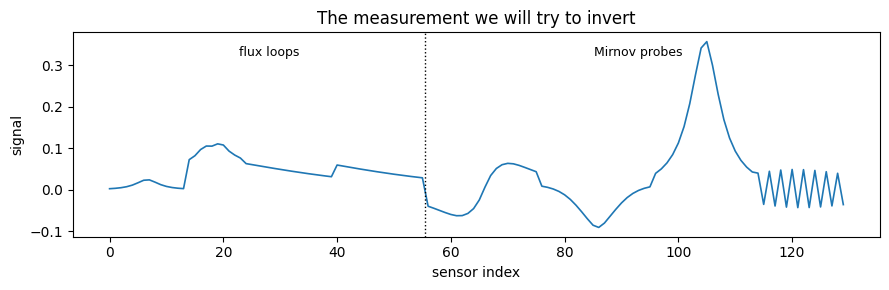

In [2]:
true_params = np.array([1.5e5, 0.32, 0.01, 0.14])   # Ip [A], R0 [m], Z0 [m], a [m]
clean = forward_signals(*true_params, layout)

for name, unit, val in zip(PARAM_NAMES, PARAM_UNITS, true_params):
    print(f"  {name:<4} = {val:>12.4f} {unit}")

fig, ax = plt.subplots(1, 1, figsize=(9, 3))
ax.plot(clean, lw=1.2)
ax.axvline(len(layout.fl_R) - 0.5, color="k", ls=":", lw=1)
ax.text(len(layout.fl_R) / 2, ax.get_ylim()[1] * 0.85, "flux loops",
        ha="center", fontsize=9)
ax.text(len(layout.fl_R) + len(layout.mp_R) / 2, ax.get_ylim()[1] * 0.85,
        "Mirnov probes", ha="center", fontsize=9)
ax.set_xlabel("sensor index")
ax.set_ylabel("signal")
ax.set_title("The measurement we will try to invert")
plt.tight_layout()
plt.show()

## What "inverting" means here

There is no formula that takes 130 numbers and returns the plasma. Instead we
search. Pick a candidate plasma, run it through the same forward model, and
compare the predicted signals to the measured ones. The mismatch is the
**residual**. Then adjust the candidate to make the residual smaller, and
repeat until it stops improving.

`invert_least_squares` does exactly this with SciPy's trust-region
least-squares. Two details in `src/ml/baseline.py` matter:

- The four parameters are rescaled to roughly the same size before the solve.
  Otherwise `Ip` (about 1e5) would completely dominate `a` (about 0.1) and the
  optimizer would be badly conditioned.
- The search is bounded to the physical parameter ranges, which stops it
  wandering into nonsense during early iterations.

In [3]:
t0 = time.perf_counter()
est_clean = invert_least_squares(clean, layout)
dt_clean = time.perf_counter() - t0

print(f"{'parameter':<10}{'true':>13}{'recovered':>13}{'rel. error':>13}")
for name, t, e in zip(PARAM_NAMES, true_params, est_clean):
    print(f"{name:<10}{t:>13.4f}{e:>13.4f}{abs(e - t) / abs(t):>12.2%}")
print(f"\nconverged in {dt_clean * 1e3:.1f} ms")

parameter          true    recovered   rel. error
Ip          150000.0000  149999.9998       0.00%
R0               0.3200       0.3200       0.00%
Z0               0.0100       0.0100       0.00%
a                0.1400       0.1400       0.00%

converged in 10.0 ms


## Read that result carefully: it is not a success

The recovery is exact to about ten decimal places. That looks like a triumph
and it is not one. We generated the signals with `forward_signals` and then
inverted them by asking `forward_signals` to match itself. The model that made
the data is the model doing the fitting, so a perfect answer exists and the
optimizer only has to find it.

This is a known trap with a name: an **inverse crime**. Doing it deliberately
is fine as long as you say so, because it does test something real: that the
optimizer converges, that the scaling and bounds work, and that the problem is
not degenerate. It just does not test the physics.

The honest checks are the two that follow: what noise does, and what it costs.

## Why the reduced model, and not TokaMaker

Notebook 01 computed sensor signals from genuine Grad-Shafranov equilibria.
Here we use the reduced model instead: a rigid disk of circular current
filaments, evaluated analytically. The reason is structural rather than
convenience.

Look at what the inversion loop does. Every iteration calls the forward model
at least once, and a converged solve takes tens of iterations. Inverting the
*real* physics would therefore mean **running TokaMaker inside the optimizer
loop**, once or more per iteration, for every shot reconstructed.

At roughly 261 ms per TokaMaker solve, measured on the 2000-equilibrium
dataset in `data/gs_dataset.npz`, a single reconstruction would take on the
order of ten seconds instead of the milliseconds we are about to measure.

So the reduced model is not a shortcut taken to make the notebook tidy. The
cost of the real inverse problem is the thing that motivates a surrogate at
all. Notebook 03 picks this up.

**What this costs us in honesty:** the benchmark in notebook 03 is a learned
surrogate against a classical inversion *of the same reduced physics*. Both
invert identical equations, so the comparison is fair, but neither is
reconstructing a real Grad-Shafranov equilibrium. `data/gs_dataset.npz` holds
2000 real ones, and training on those is the documented next step.

## Now the honest test: measurement noise

Real magnetics are noisy. `noisy_replicas` holds the plasma **fixed** and
re-rolls only the measurement noise, so every replica has identical ground
truth. Any spread in the recovered parameters is therefore caused by noise
alone, not by the plasma changing between attempts.

The noise here is 2% Gaussian per channel. That figure is invented, not
measured from CUTE, and it is the single largest unverified assumption in this
whole pipeline. Real magnetic diagnostics can be correlated, drifting or
spiky, and if they are, everything below changes.

In [4]:
n_rep = 40
X_noisy, _ = noisy_replicas(true_params, n_replicas=n_rep, noise_frac=0.02,
                            seed=1, layout=layout)

t0 = time.perf_counter()
ests = np.array([invert_least_squares(x, layout) for x in X_noisy])
dt_noisy = (time.perf_counter() - t0) / n_rep

print(f"{n_rep} reconstructions of the SAME plasma, 2% sensor noise\n")
# Scatter is reported as a fraction of each parameter's SAMPLED RANGE, not of
# its true value. Z0 is centred on zero, so dividing by the true value would
# make a perfectly good reconstruction look terrible purely because the
# denominator is small. Fraction of range compares the four fairly.
print(f"{'parameter':<10}{'true':>13}{'mean':>13}{'std':>12}{'std/range':>12}")
for j, name in enumerate(PARAM_NAMES):
    col = ests[:, j]
    lo, hi = PARAM_RANGES[name]
    print(f"{name:<10}{true_params[j]:>13.4f}{col.mean():>13.4f}"
          f"{col.std():>12.4f}{col.std() / (hi - lo):>11.2%}")
print(f"\nmean solve time {dt_noisy * 1e3:.1f} ms")

40 reconstructions of the SAME plasma, 2% sensor noise

parameter          true         mean         std   std/range
Ip          150000.0000  150005.5339    726.3094      0.32%
R0               0.3200       0.3200      0.0009      1.18%
Z0               0.0100       0.0100      0.0008      0.70%
a                0.1400       0.1394      0.0025      1.91%

mean solve time 10.2 ms


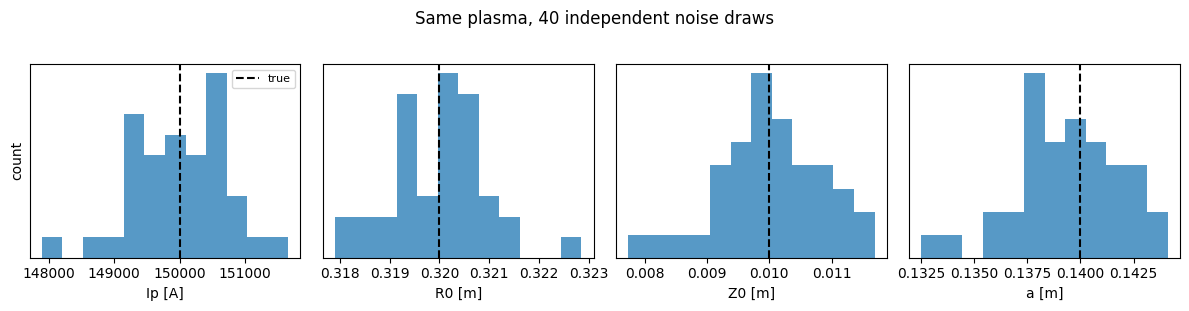

In [5]:
fig, axes = plt.subplots(1, 4, figsize=(12, 3))
for j, (ax, name, unit) in enumerate(zip(axes, PARAM_NAMES, PARAM_UNITS)):
    ax.hist(ests[:, j], bins=12, color="tab:blue", alpha=0.75)
    ax.axvline(true_params[j], color="k", ls="--", lw=1.5, label="true")
    ax.set_xlabel(f"{name} [{unit}]")
    ax.set_yticks([])
    if j == 0:
        ax.legend(fontsize=8)
axes[0].set_ylabel("count")
fig.suptitle("Same plasma, 40 independent noise draws", y=1.02)
plt.tight_layout()
plt.show()

### Where the error lands, and why it is not spread evenly

The scatter is not the same for every parameter. Measured against each
parameter's sampled range, `Ip` comes back tightest and the minor radius `a` is
consistently the worst, with the two positions in between.

The choice of denominator in that table is worth pausing on, because it changes
the conclusion. Dividing the scatter by each parameter's *true value* would
report `Z0` as by far the worst, at several percent. That would be an artifact:
`Z0` is centred on zero, so a small absolute error divided by a near-zero true
value looks enormous. Nothing about the reconstruction is worse there. Choosing
a denominator that flatters or damns a result is an easy way to mislead
yourself, so the range is used instead.

The reason is physical rather than numerical. The sensors sit outside the
plasma, and from outside, a compact plasma and a slightly broader one carrying
the same total current produce very nearly the same external field. Total
current and current *position* imprint strongly on the outside world. How that
current is spread out does not.

This is a property of the measurement, not of the algorithm, so a better
optimizer would not fix it. Notebook 03 shows the learned surrogate inheriting
exactly the same weakness, which is a useful sign that it learned the physics
rather than memorizing the training set.

## What it costs

The point that carries into notebook 03. Each reconstruction is an independent
iterative optimization: no work is shared between shots, so reconstructing
1000 shots costs 1000 times as much as reconstructing one.

In [6]:
n_bench = 25
rng = np.random.default_rng(7)
batch = np.array([forward_signals(*p, layout) for p in
                  np.column_stack([rng.uniform(5.0e4, 2.0e5, n_bench),
                                   rng.uniform(0.30, 0.34, n_bench),
                                   rng.uniform(-0.03, 0.03, n_bench),
                                   rng.uniform(0.10, 0.16, n_bench)])])

t0 = time.perf_counter()
for x in batch:
    invert_least_squares(x, layout)
per_shot = (time.perf_counter() - t0) / n_bench

print(f"classical inversion: {per_shot * 1e3:.1f} ms per shot")
print(f"  1000 shots would take {per_shot * 1000:.1f} s")
print(f"  a 10,000-shot scan would take {per_shot * 10000 / 60:.1f} min")

classical inversion: 9.2 ms per shot
  1000 shots would take 9.2 s
  a 10,000-shot scan would take 1.5 min


## What this sets up

Two facts to carry forward:

1. **The classical inversion works.** On this reduced physics it is accurate,
   and its error structure is physically sensible: positions and total current
   are well determined, minor radius is not.
2. **It does not amortize.** Every shot pays the full iterative cost again.

A learned surrogate attacks the second point specifically. It moves the cost
into a one-off training step, after which each reconstruction is a single
forward pass through a small network. Notebook 03 builds one, benchmarks it
against the inversion measured here, and then looks for the ways it fails.

The benchmark is meaningful precisely because both methods invert the same
reduced physics. That is a deliberately conservative comparison, and it is the
one stated in the README.